<!-- AI-og-helse: colab-kontrakt v1 -->

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/AI-og-helse/blob/main/uke05-agentisk-ai/03_crewai_fordypning_rehabilitering.ipynb)

## Colab-kjøring

- **Anbefalt runtime:** CPU
- **Forventet kjøretid:** 30-60 min
- **Datamønster:** `api-secrets`

**Krav før kjøring:**
- API: GOOGLE_API_KEY eller GEMINI_API_KEY
- Data: syntetisk rehabiliteringscase
- GPU: ikke nødvendig

**Felles konvensjon:** Kjør setup-cellen rett under først. I Colab hentes hemmeligheter fra **Secrets** med `userdata.get(...)`; lokalt brukes miljøvariabler eller `.env`.

Kjør cellene ovenfra og ned. Setup-cellen installerer bare ekstra pakker når notebooken åpnes i Colab.


In [ ]:
# AI-og-helse: Colab bootstrap v1
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
NOTEBOOK_PACKAGES = [('crewai', 'crewai'), ('google-genai', 'google.genai'), ('python-dotenv', 'dotenv')]
COLAB_DATA_MODE = 'api-secrets'


def _has_import(import_name: str) -> bool:
    return importlib.util.find_spec(import_name) is not None


def ensure_packages(packages=NOTEBOOK_PACKAGES):
    """Install only notebook-specific packages when running in Colab."""
    if not IN_COLAB:
        return

    missing = [package for package, import_name in packages if not _has_import(import_name)]
    if missing:
        print("Installerer Colab-pakker:", ", ".join(missing))
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    else:
        print("Alle notebook-spesifikke Colab-pakker er tilgjengelige.")


def get_secret(name: str, *aliases: str):
    """Read secrets from environment/.env locally or Colab Secrets in Colab."""
    for key in (name, *aliases):
        value = os.getenv(key)
        if value:
            os.environ[name] = value
            return value

    if IN_COLAB:
        try:
            from google.colab import userdata
        except Exception:
            userdata = None

        if userdata is not None:
            for key in (name, *aliases):
                try:
                    value = userdata.get(key)
                except Exception:
                    value = None
                if value:
                    os.environ[name] = value
                    return value

    return None


def mount_drive_if_needed():
    """Mount Google Drive explicitly in notebooks that need persistent artifacts."""
    if not IN_COLAB:
        return None
    from google.colab import drive

    drive.mount("/content/drive")
    return Path("/content/drive/MyDrive")


ensure_packages()
print("Miljø:", "Google Colab" if IN_COLAB else "lokalt")
print("Datamønster:", COLAB_DATA_MODE)


# Fordypning: CrewAI i rehabilitering

## Læringsmål

| Etter notebooken bør du kunne | Hvorfor dette er viktig i helse og omsorg |
|---|---|
| Forklare hvordan et lite `CrewAI`-oppsett kan organiseres som et tverrfaglig team rundt et rehabiliteringscase. | Multi-agent-systemer blir lettere å forstå når de kobles til roller som ligner reelle samarbeidsformer i helse og omsorg. |
| Beskrive forskjellen mellom `Agent`, `Task`, `Tool` og `Crew` i et konkret eksempel. | Begrepene blir mer nyttige når de forstås som deler av en arbeidsflyt, ikke bare som tekniske ord. |
| Se hvordan en lett Gemini-modell kan brukes i en avgrenset undervisningsdemo med syntetiske data. | Det gjør det lettere å prøve ut agentisk AI på en trygg og praktisk måte. |
| Reflektere over hvorfor menneskelig kontroll fortsatt må være tydelig, selv i et mer avansert oppsett. | I helse er ansvar, kvalitetssikring og faglig vurdering viktigere jo mer autonomt systemet virker. |

<br>

> **Merk:** Dette er pedagogisk materiale. Eksemplet er laget for læring og refleksjon, ikke for klinisk beslutningsstøtte.

Denne notebooken er et frivillig fordypningsspor til uke 05. Den bygger videre på skillet mellom chatbot, workflow og agent, og viser hvordan et lite `CrewAI`-oppsett kan brukes til å simulere et tverrfaglig rehabiliteringsteam rundt et syntetisk case.

Hvis du vil løfte blikket fra selve demoen til mer overordnede spørsmål om framtidig bruk, arkitektur, styring og lokale modeller, kan du deretter gå videre til `04_agentisk_ai_perspektiver.ipynb`.


## Installering og setup

Hvis du kjører denne notebooken i Google Colab, er den enkleste oppskriften vanligvis:

- installer `crewai`
- legg inn `GOOGLE_API_KEY` eller `GEMINI_API_KEY`
- bruk en lett Gemini-modell, for eksempel `gemini/gemini-2.5-flash`

Denne notebooken bruker syntetiske data, så en gratis eller rimelig Gemini-modell er som regel tilstrekkelig. Bruk ikke ekte pasientopplysninger i et slikt oppsett.


### Korte steg i Colab

Hvis du vil teste demoen i Colab, kan du gjøre dette:

1. Åpne notebooken i Colab.
2. Kjør installasjons- og setup-cellen.
3. Lim inn `GOOGLE_API_KEY` når du blir spurt.
4. Kjør cellene for case, agenter og `CrewAI`.

Hvis alt er satt opp riktig, vil du få et strukturert undervisningsutkast fra det tverrfaglige rehabiliteringsteamet.


## Hva skal eksemplet vise?

I de forrige notebookene sa vi at agentisk AI blir interessant når en oppgave krever flere steg, flere perspektiver eller bruk av verktøy underveis. Her tar vi det ett steg videre:

- En agent vurderer funksjon og mobilitet.
- En agent vurderer kommunikasjon og informasjonstilpasning.
- En agent vurderer egenomsorg og hjemmeoppfølging.
- En koordinator samler alt i en strukturert plan.

Poenget er ikke at systemet skal overta faglige vurderinger. Poenget er å se hvordan et multi-agent oppsett kan organisere arbeidsdeling, struktur og sporbarhet.

For å kjøre koden trenger du vanligvis en installert `crewai`-pakke og tilgang til en Gemini API-nøkkel. I setup-cellen under sjekker vi om `GOOGLE_API_KEY` eller `GEMINI_API_KEY` finnes, og hvis du bruker notebooken interaktivt kan du også lime nøkkelen inn direkte. Vi bruker en lett Gemini-modell som standard for at demoen skal være enkel å kjøre med syntetiske data.


<details>
<summary><strong>Tenk selv</strong></summary>

Før du ser på koden: Hvilken av de fire rollene i dette rehabiliteringsoppsettet virker mest tydelig avgrenset, og hvilken virker mest sårbar for misforståelser?

</details>

<details>
<summary><strong>Mulig svar</strong></summary>

Et mulig svar er at koordinatorrollen kan være nyttig fordi den samler delene, men også sårbar fordi den lett kan gi inntrykk av en helhetlig vurdering. Nettopp derfor må resultatet presenteres som et utkast for menneskelig gjennomgang.

</details>

<br>

> **Faglig poeng:** Når flere roller samarbeider, blir tydelig rolleavgrensning enda viktigere.


In [1]:
# Eventuell installasjon i Colab eller ny notebook-kjerne:
# %pip install -q crewai python-dotenv

import os
from getpass import getpass
from importlib.metadata import PackageNotFoundError, version

# Last inn .env hvis python-dotenv er tilgjengelig.
try:
    from dotenv import load_dotenv

    load_dotenv()
    DOTENV_LOADED = True
except ImportError:
    DOTENV_LOADED = False

# Vis installert CrewAI-versjon dersom pakken finnes.
try:
    CREWAI_VERSION = version("crewai")
except PackageNotFoundError:
    CREWAI_VERSION = "ikke installert ennå"

# Standardmodell for en lett undervisningsdemo.
# Du kan overstyre denne via GEMINI_MODEL i miljøet eller i .env.
DEFAULT_GEMINI_MODEL = "gemini/gemini-2.5-flash"

# 1. Prøv å lese API-nøkkelen fra miljøet eller .env.
# Støtter både GOOGLE_API_KEY og GEMINI_API_KEY.
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY") or os.getenv("GEMINI_API_KEY")

# Hvis vi fant en nøkkel via GEMINI_API_KEY, eksporter den også som GOOGLE_API_KEY
# slik at resten av notebooken og CrewAI kan bruke ett konsistent navn.
if GOOGLE_API_KEY:
    os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

# 2. Hvis nøkkelen ikke finnes, prøv å be brukeren lime den inn.
# Dette fungerer både i Colab og ofte i vanlig Jupyter.
if not GOOGLE_API_KEY:
    try:
        from IPython import get_ipython

        if get_ipython() is not None:
            GOOGLE_API_KEY = getpass("Lim inn Gemini API-nøkkel (skjult): ").strip()
            if GOOGLE_API_KEY:
                os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY
    except Exception:
        pass

# 3. Velg modell. Du kan overstyre denne via miljøet med GEMINI_MODEL.
GEMINI_MODEL = os.getenv("GEMINI_MODEL", DEFAULT_GEMINI_MODEL)

print("CrewAI-versjon:", CREWAI_VERSION)
print("Valgt modell:", GEMINI_MODEL)
print(".env lastet:", DOTENV_LOADED)
print("GOOGLE_API_KEY funnet:", bool(GOOGLE_API_KEY))

if not DOTENV_LOADED:
    print("Tips: Installer python-dotenv hvis du vil lese nøkler automatisk fra .env.")

if not GOOGLE_API_KEY:
    print("API-nøkkel mangler. Notebooken støtter både GOOGLE_API_KEY og GEMINI_API_KEY i .env eller miljøet.")

print("Tips: Hvis du får 404 for en Gemini-modell, sett for eksempel GEMINI_MODEL=gemini/gemini-2.5-flash i .env eller miljøet og kjør setup-cellen på nytt.")


CrewAI-versjon: 1.12.2
Valgt modell: gemini/gemini-2.5-flash
.env lastet: True
GOOGLE_API_KEY funnet: True
Tips: Hvis du får 404 for en Gemini-modell, sett for eksempel GEMINI_MODEL=gemini/gemini-2.5-flash i .env eller miljøet og kjør setup-cellen på nytt.


In [2]:
from pprint import pprint

# Syntetisk rehabiliteringscase
case_text = """
Pasient, 78 år, etter hjerneslag.
Bor alene. Redusert gangfunksjon og usikker balanse.
Glemmer iblant medisiner. Trenger hjelp til handling og praktiske oppgaver.
Mål: kunne bo trygt hjemme og mestre daglige aktiviteter best mulig.
"""


def case_reader(text: str) -> str:
    return text.strip()


def rehab_checklist_tool() -> str:
    return """
    Rehabiliteringssjekkliste:
    - mobilitet og balanse
    - ADL-funksjon
    - kommunikasjon og informasjonstilpasning
    - medikamenthåndtering
    - hjemmeoppfølging
    - pårørende og samhandling
    """.strip()


def local_guideline_lookup(topic: str) -> str:
    knowledge = {
        "fallrisiko": "Ved redusert balanse bør tiltak for fallforebygging vurderes.",
        "egenomsorg": "Ved nedsatt egenmestring bør behov for praktisk bistand vurderes.",
        "medikamenter": "Ved usikker legemiddelhåndtering bør oppfølging og kontrollrutiner avklares.",
    }
    return knowledge.get(topic.lower(), "Ingen direkte match i kunnskapsbasen.")


def uncertainty_flagger(text: str) -> str:
    return {
        "undervisningsutkast": True,
        "menneskelig_kontroll": "Obligatorisk for alle klinisk relevante forslag.",
        "resultat": text,
    }


print("CASE")
print(case_reader(case_text))

print("\nSJEKKLISTE")
print(rehab_checklist_tool())

print("\nEKSEMPEL PÅ LOKALT OPPSLAG")
pprint(
    {
        "fallrisiko": local_guideline_lookup("fallrisiko"),
        "egenomsorg": local_guideline_lookup("egenomsorg"),
        "medikamenter": local_guideline_lookup("medikamenter"),
    }
)


CASE
Pasient, 78 år, etter hjerneslag.
Bor alene. Redusert gangfunksjon og usikker balanse.
Glemmer iblant medisiner. Trenger hjelp til handling og praktiske oppgaver.
Mål: kunne bo trygt hjemme og mestre daglige aktiviteter best mulig.

SJEKKLISTE
Rehabiliteringssjekkliste:
    - mobilitet og balanse
    - ADL-funksjon
    - kommunikasjon og informasjonstilpasning
    - medikamenthåndtering
    - hjemmeoppfølging
    - pårørende og samhandling

EKSEMPEL PÅ LOKALT OPPSLAG
{'egenomsorg': 'Ved nedsatt egenmestring bør behov for praktisk bistand '
               'vurderes.',
 'fallrisiko': 'Ved redusert balanse bør tiltak for fallforebygging vurderes.',
 'medikamenter': 'Ved usikker legemiddelhåndtering bør oppfølging og '
                 'kontrollrutiner avklares.'}


## Fra enkel agent til crew

I notebook `02_agentisk_ai_i_helse.ipynb` sa vi at en enkel agent kan velge verktøy, hente kontekst og lage et forslag. I et `CrewAI`-oppsett fordeles samme type oppgave på flere roller.

I dette mini-eksemplet bruker vi fire agenter:

- `Funksjonsagent`: vurderer mobilitet, ADL og fallrisiko.
- `Kommunikasjonsagent`: vurderer behov for tilpasset informasjon.
- `Omsorgsagent`: vurderer egenomsorg, medisiner og hjemmeoppfølging.
- `Koordinatoragent`: samler delvurderingene i en strukturert plan.

Legg merke til at agentene ikke skal stille diagnose eller ta selvstendige kliniske beslutninger. De skal lage et strukturert utkast som senere må vurderes av et menneske.


## Visuelle skisser av oppsettet

Før vi går inn i koden, kan det være nyttig å se oppsettet som en enkel arbeidsflyt. Figurene under er pedagogiske skisser: de viser ikke alle tekniske detaljer i `CrewAI`, men de gjør det lettere å se hvem som gjør hva, hvilke hjelpemidler som brukes, og hvor menneskelig kontroll kommer inn.


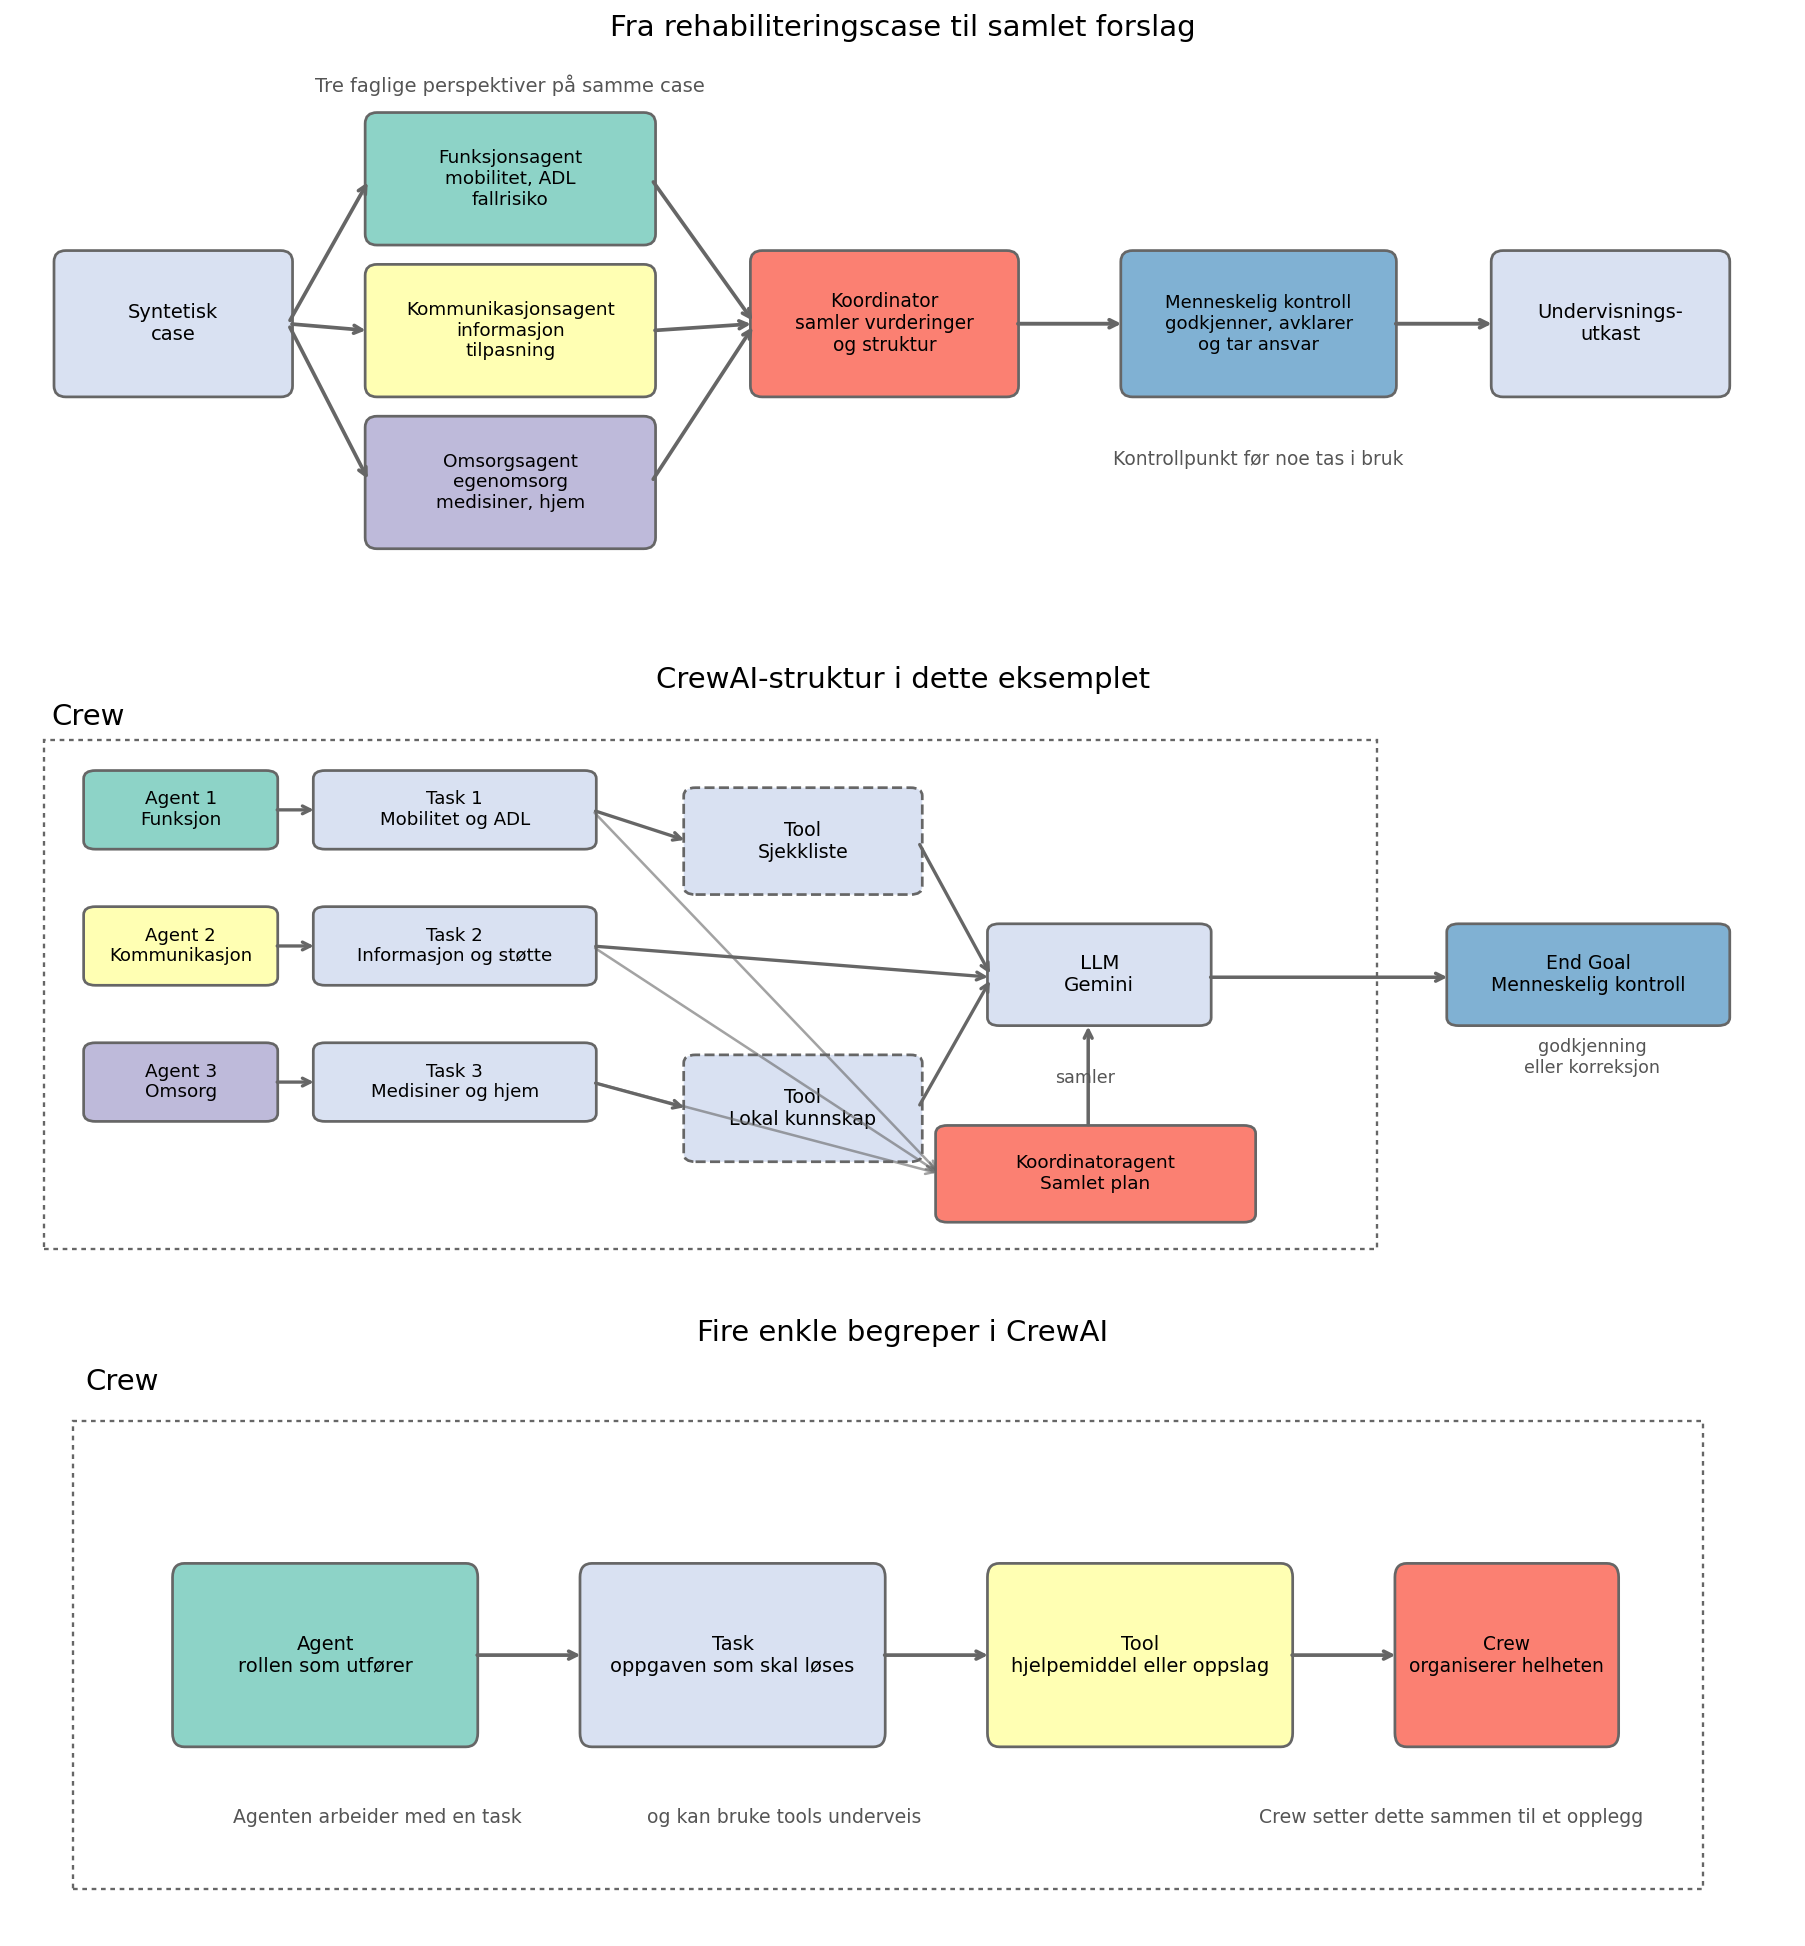

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle


plt.rcParams["figure.dpi"] = 140

PALETT = {
    "funksjon": "#8dd3c7",
    "kommunikasjon": "#ffffb3",
    "omsorg": "#bebada",
    "koordinator": "#fb8072",
    "kontroll": "#80b1d3",
    "noytral": "#d9e1f2",
    "tool": "#d9e1f2",
}
EDGE = "#666666"
TEXT = "#555555"


def add_box(ax, x, y, w, h, text, facecolor, edgecolor=EDGE, fontsize=10, linestyle="solid"):
    box = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.03,rounding_size=0.08",
        linewidth=1.4,
        edgecolor=edgecolor,
        facecolor=facecolor,
        linestyle=linestyle,
    )
    ax.add_patch(box)
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fontsize)
    return box


fig, axes = plt.subplots(3, 1, figsize=(13, 14))

# Visualisering 1: fra case til koordinert undervisningsutkast.
ax = axes[0]
ax.set_title("Fra rehabiliteringscase til samlet forslag", fontsize=15)

add_box(ax, 0.3, 2.0, 1.55, 1.0, "Syntetisk\ncase", PALETT["noytral"], fontsize=10)
add_box(ax, 2.4, 3.1, 1.9, 0.9, "Funksjonsagent\nmobilitet, ADL\nfallrisiko", PALETT["funksjon"], fontsize=9.5)
add_box(ax, 2.4, 2.0, 1.9, 0.9, "Kommunikasjonsagent\ninformasjon\ntilpasning", PALETT["kommunikasjon"], fontsize=9.5)
add_box(ax, 2.4, 0.9, 1.9, 0.9, "Omsorgsagent\negenomsorg\nmedisiner, hjem", PALETT["omsorg"], fontsize=9.5)
add_box(ax, 5.0, 2.0, 1.75, 1.0, "Koordinator\nsamler vurderinger\nog struktur", PALETT["koordinator"], fontsize=9.6)
add_box(ax, 7.5, 2.0, 1.8, 1.0, "Menneskelig kontroll\ngodkjenner, avklarer\nog tar ansvar", PALETT["kontroll"], fontsize=9.3)
add_box(ax, 10.0, 2.0, 1.55, 1.0, "Undervisnings-\nutkast", PALETT["noytral"], fontsize=10)

for y in [3.55, 2.45, 1.35]:
    ax.annotate("", xy=(2.4, y), xytext=(1.85, 2.5), arrowprops=dict(arrowstyle="->", lw=1.9, color=EDGE))

for y in [3.55, 2.45, 1.35]:
    ax.annotate("", xy=(5.0, 2.5), xytext=(4.3, y), arrowprops=dict(arrowstyle="->", lw=1.9, color=EDGE))

ax.annotate("", xy=(7.5, 2.5), xytext=(6.75, 2.5), arrowprops=dict(arrowstyle="->", lw=2.0, color=EDGE))
ax.annotate("", xy=(10.0, 2.5), xytext=(9.3, 2.5), arrowprops=dict(arrowstyle="->", lw=2.0, color=EDGE))

ax.text(3.35, 4.18, "Tre faglige perspektiver på samme case", ha="center", fontsize=10, color=TEXT)
ax.text(8.4, 1.48, "Kontrollpunkt før noe tas i bruk", ha="center", fontsize=9.6, color=TEXT)
ax.set_xlim(0, 12)
ax.set_ylim(0.3, 4.5)
ax.axis("off")

# Visualisering 2: CrewAI-oppsett som ligner referansefiguren.
ax = axes[1]
ax.set_title("CrewAI-struktur i dette eksemplet", fontsize=15)

crew_boundary = Rectangle((0.2, 0.45), 9.0, 5.05, fill=False, linestyle=(0, (2, 2)), linewidth=1.2, edgecolor=EDGE)
ax.add_patch(crew_boundary)
ax.text(0.25, 5.65, "Crew", fontsize=15, ha="left")

add_box(ax, 0.5, 4.45, 1.25, 0.72, "Agent 1\nFunksjon", PALETT["funksjon"], fontsize=9.5)
add_box(ax, 0.5, 3.1, 1.25, 0.72, "Agent 2\nKommunikasjon", PALETT["kommunikasjon"], fontsize=9.3)
add_box(ax, 0.5, 1.75, 1.25, 0.72, "Agent 3\nOmsorg", PALETT["omsorg"], fontsize=9.5)

add_box(ax, 2.05, 4.45, 1.85, 0.72, "Task 1\nMobilitet og ADL", PALETT["noytral"], fontsize=9.4)
add_box(ax, 2.05, 3.1, 1.85, 0.72, "Task 2\nInformasjon og støtte", PALETT["noytral"], fontsize=9.4)
add_box(ax, 2.05, 1.75, 1.85, 0.72, "Task 3\nMedisiner og hjem", PALETT["noytral"], fontsize=9.4)

add_box(ax, 4.55, 4.0, 1.55, 1.0, "Tool\nSjekkliste", PALETT["tool"], fontsize=9.8, linestyle="dashed")
add_box(ax, 4.55, 1.35, 1.55, 1.0, "Tool\nLokal kunnskap", PALETT["tool"], fontsize=9.8, linestyle="dashed")
add_box(ax, 6.6, 2.7, 1.45, 0.95, "LLM\nGemini", PALETT["noytral"], fontsize=10.2)
add_box(ax, 6.25, 0.75, 2.1, 0.9, "Koordinatoragent\nSamlet plan", PALETT["koordinator"], fontsize=9.5)
add_box(ax, 9.7, 2.7, 1.85, 0.95, "End Goal\nMenneskelig kontroll", PALETT["kontroll"], fontsize=9.7)

for y_agent, y_task in [(4.81, 4.81), (3.46, 3.46), (2.11, 2.11)]:
    ax.annotate("", xy=(2.05, y_task), xytext=(1.75, y_agent), arrowprops=dict(arrowstyle="->", lw=1.7, color=EDGE))

ax.annotate("", xy=(4.55, 4.5), xytext=(3.9, 4.81), arrowprops=dict(arrowstyle="->", lw=1.7, color=EDGE))
ax.annotate("", xy=(6.6, 3.15), xytext=(6.1, 4.5), arrowprops=dict(arrowstyle="->", lw=1.7, color=EDGE))
ax.annotate("", xy=(6.6, 3.15), xytext=(3.9, 3.46), arrowprops=dict(arrowstyle="->", lw=1.7, color=EDGE))
ax.annotate("", xy=(4.55, 1.85), xytext=(3.9, 2.11), arrowprops=dict(arrowstyle="->", lw=1.7, color=EDGE))
ax.annotate("", xy=(6.6, 3.15), xytext=(6.1, 1.85), arrowprops=dict(arrowstyle="->", lw=1.7, color=EDGE))

for y in [4.81, 3.46, 2.11]:
    ax.annotate("", xy=(6.25, 1.2), xytext=(3.9, y), arrowprops=dict(arrowstyle="->", lw=1.3, color=EDGE, alpha=0.6))

ax.annotate("", xy=(7.25, 2.7), xytext=(7.25, 1.65), arrowprops=dict(arrowstyle="->", lw=1.8, color=EDGE))
ax.annotate("", xy=(9.7, 3.15), xytext=(8.05, 3.15), arrowprops=dict(arrowstyle="->", lw=1.8, color=EDGE))

ax.text(7.23, 2.1, "samler", fontsize=9, ha="center", color=TEXT)
ax.text(10.65, 2.2, "godkjenning\neller korreksjon", fontsize=9, ha="center", color=TEXT)
ax.set_xlim(0, 12)
ax.set_ylim(0.15, 5.9)
ax.axis("off")

# Visualisering 3: helt enkel begrepsfigur for ferske deltakere.
ax = axes[2]
ax.set_title("Fire enkle begreper i CrewAI", fontsize=15)

crew_boundary = Rectangle((0.4, 0.8), 11.0, 2.7, fill=False, linestyle=(0, (2, 2)), linewidth=1.2, edgecolor=EDGE)
ax.add_patch(crew_boundary)
ax.text(0.48, 3.68, "Crew", fontsize=15, ha="left")

add_box(ax, 1.1, 1.65, 2.0, 1.0, "Agent\nrollen som utfører", PALETT["funksjon"], fontsize=10)
add_box(ax, 3.85, 1.65, 2.0, 1.0, "Task\noppgaven som skal løses", PALETT["noytral"], fontsize=10)
add_box(ax, 6.6, 1.65, 2.0, 1.0, "Tool\nhjelpemiddel eller oppslag", PALETT["kommunikasjon"], fontsize=10)
add_box(ax, 9.35, 1.65, 1.45, 1.0, "Crew\norganiserer helheten", PALETT["koordinator"], fontsize=9.6)

ax.annotate("", xy=(3.85, 2.15), xytext=(3.1, 2.15), arrowprops=dict(arrowstyle="->", lw=1.9, color=EDGE))
ax.annotate("", xy=(6.6, 2.15), xytext=(5.85, 2.15), arrowprops=dict(arrowstyle="->", lw=1.9, color=EDGE))
ax.annotate("", xy=(9.35, 2.15), xytext=(8.6, 2.15), arrowprops=dict(arrowstyle="->", lw=1.9, color=EDGE))

ax.text(2.45, 1.18, "Agenten arbeider med en task", ha="center", fontsize=9.7, color=TEXT)
ax.text(5.2, 1.18, "og kan bruke tools underveis", ha="center", fontsize=9.7, color=TEXT)
ax.text(9.7, 1.18, "Crew setter dette sammen til et opplegg", ha="center", fontsize=9.7, color=TEXT)
ax.set_xlim(0, 12)
ax.set_ylim(0.55, 3.9)
ax.axis("off")

plt.tight_layout(h_pad=2.0)
plt.show()


*Les figurene som pedagogiske skisser, ikke som full teknisk dokumentasjon av `CrewAI`.*


In [4]:
from IPython.display import Markdown, display
from crewai import Agent, Task, Crew, Process, LLM


GOOGLE_API_KEY = GOOGLE_API_KEY or os.getenv("GOOGLE_API_KEY")

if not GOOGLE_API_KEY:
    raise ValueError(
        "GOOGLE_API_KEY mangler. Kjør setup-cellen over først og lim inn nøkkelen, "
        "eller sett miljøvariabelen før du kjører CrewAI-cellen."
    )


print(f"Kjører CrewAI {CREWAI_VERSION} med modell: {GEMINI_MODEL}")

# Én delt LLM-konfigurasjon brukes av alle agentene.
# Det gjør eksemplet enklere å lese og enklere å endre senere.
llm = LLM(
    model=GEMINI_MODEL,
    temperature=0.2,
)


# Agent = en rolle med et faglig perspektiv, et mål og en språkmodell.
# Her lager vi fire roller som sammen ligner et lite tverrfaglig team.
funksjonsagent = Agent(
    role="Funksjonsagent",
    goal="Vurdere mobilitet, ADL, fallrisiko og rehabiliteringsmål.",
    backstory="Har et fysioterapeutisk og funksjonsorientert perspektiv.",
    llm=llm,
    verbose=False,
)

kommunikasjonsagent = Agent(
    role="Kommunikasjonsagent",
    goal="Vurdere behov for tilpasset informasjon og kommunikasjon.",
    backstory="Har fokus på pasientforståelse, kommunikasjon og oppfølging.",
    llm=llm,
    verbose=False,
)

omsorgsagent = Agent(
    role="Omsorgsagent",
    goal="Vurdere egenomsorg, medikamenthåndtering og hjemmeoppfølging.",
    backstory="Har et sykepleiefaglig og kommunalt oppfølgingsperspektiv.",
    llm=llm,
    verbose=False,
)

koordinatoragent = Agent(
    role="Koordinatoragent",
    goal="Samle vurderingene i en strukturert plan med tydelige forbehold.",
    backstory="Har ansvar for samordning og menneske-i-loopen.",
    llm=llm,
    verbose=False,
)


# Task = den konkrete arbeidsoppgaven en agent skal utføre.
# Beskrivelsen avgrenser hva agenten skal gjøre, og expected_output sier noe om ønsket format.
task_funksjon = Task(
    description=f"""
    Les caset:
    {case_reader(case_text)}

    Bruk sjekklisten:
    {rehab_checklist_tool()}

    Lag en kort vurdering av mobilitet, fallrisiko, ADL og rehabiliteringsmål.
    Ikke still diagnose eller gi behandlingsordre.
    """,
    expected_output="Kort funksjonsvurdering med forbehold.",
    agent=funksjonsagent,
)

task_kommunikasjon = Task(
    description=f"""
    Les caset:
    {case_reader(case_text)}

    Vurder behov for tilpasset informasjon, kommunikasjon og oppfølging.
    Ikke anta mer enn det som står i caset.
    """,
    expected_output="Kort vurdering av kommunikasjon og informasjonsbehov.",
    agent=kommunikasjonsagent,
)

task_omsorg = Task(
    description=f"""
    Les caset:
    {case_reader(case_text)}

    Bruk ved behov:
    - {local_guideline_lookup('fallrisiko')}
    - {local_guideline_lookup('egenomsorg')}
    - {local_guideline_lookup('medikamenter')}

    Vurder egenomsorg, medikamenthåndtering og behov for hjemmeoppfølging.
    Ikke anta tilgang til andre data enn det som er oppgitt her.
    """,
    expected_output="Kort omsorgsvurdering med praktiske forslag og forbehold.",
    agent=omsorgsagent,
)

task_koordinering = Task(
    description="""
    Samle de tre delvurderingene i en strukturert rehabiliteringsplan.

    Bruk overskriftene:
    - hovedutfordringer
    - foreslåtte rehabiliteringsmål
    - foreslåtte tiltak
    - hvem som skal involveres
    - hva som må avklares av menneskelig fagperson
    - forbehold og usikkerhet

    Avslutt med tydelig melding om at dette kun er et undervisningsutkast.
    """,
    expected_output="Samlet rehabiliteringsplan for menneskelig vurdering.",
    agent=koordinatoragent,
)


# Crew = orkestreringen av hele oppsettet.
# Her bestemmer vi hvilke agenter og tasks som inngår, i hvilken rekkefølge de kjøres,
# og om vi vil ha enkel kjørelogg i notebooken via verbose=True.
# Hvis du senere vil undersøke kjøringen mer detaljert, kan tracing aktiveres i CrewAI.
rehab_crew = Crew(
    agents=[funksjonsagent, kommunikasjonsagent, omsorgsagent, koordinatoragent],
    tasks=[task_funksjon, task_kommunikasjon, task_omsorg, task_koordinering],
    process=Process.sequential,
    verbose=True,
)


resultat = rehab_crew.kickoff()
resultat_text = str(resultat)

print("SAMLET RESULTAT")
display(Markdown(resultat_text))

print("\nETTERKONTROLL")
pprint(uncertainty_flagger(resultat_text))


Kjører CrewAI 1.12.2 med modell: gemini/gemini-2.5-flash


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 5b90a74e-34c4-406c-bd29-012f852dbef4                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name:                                                                                                          │
│      Les caset:                                                                                                 │
│      Pasient, 78 år, etter hjerneslag.                                                                          │
│  Bor alene. Redusert gangfunksjon og usikker balanse.                                                           │
│  Glemmer iblant medisiner. Trenger hjelp til handling og praktiske oppgaver.                                    │
│  Mål: kunne bo trygt hjemme og mestre daglige aktiviteter best mulig.                                           │
│                                                                                                                 │
│      Bruk sjekklisten:                                                                                          │
│      Rehabiliteringssjekkliste:                                                                                 │
│      - mobilitet og balanse                                                                                     │
│      - ADL-funksjon                                                                                             │
│      - kommunikasjon og informasjonstilpasning                                                                  │
│      - medikamenthåndtering                                                                                     │
│      - hjemmeoppfølging                                                                                         │
│      - pårørende og samhandling                                                                                 │
│                                                                                                                 │
│      Lag en kort vurdering av mobilitet, fallrisiko, ADL og rehabiliteringsmål.                                 │
│      Ikke still diagnose eller gi behandlingsordre.                                                             │
│                                                                                                                 │
│  ID: 142ef9bb-d1df-4a23-8c9d-6127d6e28d5c                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Funksjonsagent                                                                                          │
│                                                                                                                 │
│  Task:                                                                                                          │
│      Les caset:                                                                                                 │
│      Pasient, 78 år, etter hjerneslag.                                                                          │
│  Bor alene. Redusert gangfunksjon og usikker balanse.                                                           │
│  Glemmer iblant medisiner. Trenger hjelp til handling og praktiske oppgaver.                                    │
│  Mål: kunne bo trygt hjemme og mestre daglige aktiviteter best mulig.                                           │
│                                                                                                                 │
│      Bruk sjekklisten:                                                                                          │
│      Rehabiliteringssjekkliste:                                                                                 │
│      - mobilitet og balanse                                                                                     │
│      - ADL-funksjon                                                                                             │
│      - kommunikasjon og informasjonstilpasning                                                                  │
│      - medikamenthåndtering                                                                                     │
│      - hjemmeoppfølging                                                                                         │
│      - pårørende og samhandling                                                                                 │
│                                                                                                                 │
│      Lag en kort vurdering av mobilitet, fallrisiko, ADL og rehabiliteringsmål.                                 │
│      Ikke still diagnose eller gi behandlingsordre.                                                             │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

SAMLET RESULTAT


**Rehabiliteringsplan – Utkast for menneskelig vurdering**

**hovedutfordringer**
*   **Redusert mobilitet og balanse:** Pasienten viser tydelig redusert gangfunksjon og usikker balanse etter hjerneslaget, noe som indikerer en betydelig funksjonsnedsettelse i forflytning og stabilitet.
*   **Høy fallrisiko:** Med bakgrunn i den usikre balansen, reduserte gangfunksjonen, pasientens alder (78 år) og det faktum at vedkommende bor alene, vurderes fallrisikoen som høy.
*   **Utfordringer med instrumentelle daglige aktiviteter (IADL):** Pasienten har behov for assistanse med IADL som handling og praktiske oppgaver. Den reduserte mobiliteten og balansen kan potensielt også påvirke grunnleggende ADL (BADL), noe som bør vurderes nærmere.
*   **Usikker medikamenthåndtering:** Pasienten glemmer medisiner iblant, noe som utgjør en alvorlig risiko for feilmedisinering (overdosering, underdosering, feil tidspunkt) og kan føre til forverret helsetilstand.
*   **Behov for tilpasset informasjon og kommunikasjon:** Kognitive utfordringer knyttet til glemsomhet krever en svært tydelig, enkel og repeterende tilnærming for informasjon om medisinering og andre tiltak.
*   **Behov for koordinert hjemmeoppfølging:** Det er et omfattende og umiddelbart behov for hjemmeoppfølging for å sikre at pasienten kan bo trygt hjemme og mestre daglige aktiviteter best mulig.

**foreslåtte rehabiliteringsmål**
*   **Trygg bosituasjon i eget hjem:** Pasienten skal kunne bo trygt i eget hjem med redusert fallrisiko og nødvendige tilpasninger.
*   **Optimalisert mestring av daglige aktiviteter:** Pasienten skal mestre daglige aktiviteter (ADL/IADL) i størst mulig grad, med nødvendig bistand og hjelpemidler.
*   **Forbedret balanse og gangfunksjon:** Pasienten skal oppnå en funksjonell forbedring i balanse og gangfunksjon for å øke selvstendighet og redusere fallrisiko.
*   **Sikker medikamenthåndtering:** Pasienten skal ha et etablert og trygt system for medikamenthåndtering for å sikre korrekt medisinering.
*   **Adekvat praktisk bistand:** Pasienten skal motta nødvendig praktisk bistand for å opprettholde et fungerende hjem og tilgang til nødvendige varer.

**foreslåtte tiltak**
*   **Fallforebygging og mobilitet:**
    *   Hjemmebesøk av ergoterapeut for en grundig vurdering av hjemmemiljøet (fjerning av snublefeller, optimalisering av belysning) og behov for hjelpemidler (f.eks. ganghjelpemiddel, støttehåndtak i bad/toalett, dusjstol).
    *   Fysioterapi for målrettet balanse- og gangtrening for å styrke funksjonen.
    *   Installering av trygghetsalarm for rask tilkalling av hjelp ved fall eller andre akutte situasjoner.
    *   Praktisk rettet informasjon og veiledning om fallforebygging, trygg forflytning og korrekt bruk av hjelpemidler, med demonstrasjon og mulighet for øving.
*   **Medikamenthåndtering:**
    *   Etablere daglig oppfølging fra hjemmesykepleie for utdeling av medisiner og/eller kontroll av medisindosett.
    *   Vurdere en automatisk medisindispenser med påminnelsesfunksjon og eventuelt varsling til pårørende/hjemmesykepleie ved manglende inntak.
    *   Anbefale en medikamentgjennomgang med lege for å sikre en optimalisert og eventuelt forenklet medisinliste.
    *   Informasjon om medisinering må være svært tydelig, enkel og repeterende, supplert med visuelle hjelpemidler som dosett og piktogrammer.
*   **Praktisk bistand og egenmestring:**
    *   Søke om praktisk bistand fra kommunen (hjemmehjelp) for handling, rengjøring og andre praktiske oppgaver i hjemmet.
    *   Vurdere behov for ferdigmatlevering eller hjelp til matlaging.
    *   Vurdere tilbud som dagsenter eller frivillige tjenester for å forebygge sosial isolasjon.
    *   Tydelig informasjon om tilgjengelige kommunale tjenester og hvordan man søker om disse.
*   **Informasjon og kommunikasjon:**
    *   Bruke et enkelt språk, unngå fagterminologi, og sjekke pasientens forståelse jevnlig (f.eks. ved å be pasienten gjenta informasjonen med egne ord).
    *   Tålmodighet og gjentakelse er nøkkelen i all kommunikasjon.
    *   Involvere pasienten aktivt i valg av hjelpemidler og tilpasninger i hjemmet.

**hvem som skal involveres**
*   **Pasienten selv:** Som den sentrale aktøren i egen rehabilitering, med aktiv involvering i planlegging og gjennomføring.
*   **Koordinator/primærkontakt:** Fra kommunen for å sikre helhetlig planlegging, koordinering og evaluering av alle tjenester.
*   **Hjemmesykepleien:** For medikamenthåndtering, generell helseoppfølging og regelmessig evaluering av behov.
*   **Fysioterapeut:** For funksjonstrening (balanse, gange) og vurdering av mobilitet og fallrisiko.
*   **Ergoterapeut:** For vurdering av hjemmemiljø, ADL-funksjon og behov for hjelpemidler/tilpasninger.
*   **Lege:** For medikamentgjennomgang, medisinsk oppfølging og vurdering av helsetilstand.
*   **Hjemmehjelp:** For praktisk bistand i hjemmet.
*   **Pårørende/sosialt nettverk:** Hvis tilgjengelig og ønskelig, for å bidra med støtte, avlastning og som en ressurs i oppfølgingen.

**hva som må avklares av menneskelig fagperson**
*   **Grad av kognitiv svikt:** En grundigere kognitiv vurdering er nødvendig for å tilpasse informasjon, kommunikasjon og tiltak optimalt, spesielt for medikamenthåndtering og evne til å følge instruksjoner.
*   **Nærmere vurdering av BADL-funksjon:** Selv om grunnleggende ADL ikke er spesifikt nevnt som utfordrende, kan den reduserte mobiliteten og balansen potensielt påvirke disse. Dette bør vurderes nærmere av ergoterapeut/sykepleier.
*   **Pasientens motivasjon og preferanser:** Kartlegging av pasientens egen motivasjon, vilje til å ta imot hjelp og delta i rehabiliterende tiltak, samt hennes ønsker og prioriteringer for hjelp.
*   **Boligens beskaffenhet:** En detaljert vurdering av boligen for å identifisere spesifikke behov for hjelpemidler og eventuelle boligtilpasninger.
*   **Omfang av sosialt nettverk:** Kartlegging av eventuelt sosialt nettverk (familie, venner) som kan bidra med støtte og avlastning, for å tilpasse omfanget av kommunale tjenester.
*   **Medisinsk stabilitet:** Vurdering av pasientens generelle medisinske tilstand etter hjerneslaget og eventuelle andre komorbiditeter som kan påvirke rehabiliteringen.

**forbehold og usikkerhet**
*   **Kognitiv funksjon:** Uten en grundig kognitiv vurdering er det usikkerhet knyttet til pasientens fulle kapasitet til å ta imot og bearbeide informasjon, samt følge komplekse instruksjoner. Dette kan påvirke effekten av tiltak, spesielt medikamenthåndtering.
*   **Pasientens egen motivasjon og deltakelse:** Effekten av rehabiliteringsplanen er sterkt avhengig av pasientens egen motivasjon, vilje til å ta imot hjelp og aktivt delta i foreslåtte tiltak.
*   **Boligens tilpasningsmuligheter:** Det er usikkert hvorvidt boligen kan tilpasses tilstrekkelig for å møte pasientens mobilitetsbehov uten større inngrep.
*   **Tilgjengelighet av ressurser:** Tilgjengeligheten av kommunale tjenester (fysioterapi, ergoterapi, hjemmesykepleie, hjemmehjelp) og eventuelle ventetider kan påvirke implementeringen av planen.
*   **Utvikling etter hjerneslag:** Pasientens funksjon kan endre seg over tid etter hjerneslaget, noe som krever kontinuerlig evaluering og justering av planen.
*   **Manglende informasjon om pårørende:** Uten informasjon om et eventuelt pårørendenettverk er det usikkerhet knyttet til muligheten for uformell støtte og avlastning.

---
Dette er kun et undervisningsutkast og en samling av vurderinger. En endelig rehabiliteringsplan må utarbeides i samarbeid med pasienten, pårørende (hvis aktuelt) og et tverrfaglig team av fagpersoner, basert på en grundig og helhetlig klinisk vurdering.


ETTERKONTROLL
{'menneskelig_kontroll': 'Obligatorisk for alle klinisk relevante forslag.',
 'resultat': '**Rehabiliteringsplan – Utkast for menneskelig vurdering**\n'
             '\n'
             '**hovedutfordringer**\n'
             '*   **Redusert mobilitet og balanse:** Pasienten viser tydelig '
             'redusert gangfunksjon og usikker balanse etter hjerneslaget, noe '
             'som indikerer en betydelig funksjonsnedsettelse i forflytning og '
             'stabilitet.\n'
             '*   **Høy fallrisiko:** Med bakgrunn i den usikre balansen, '
             'reduserte gangfunksjonen, pasientens alder (78 år) og det faktum '
             'at vedkommende bor alene, vurderes fallrisikoen som høy.\n'
             '*   **Utfordringer med instrumentelle daglige aktiviteter '
             '(IADL):** Pasienten har behov for assistanse med IADL som '
             'handling og praktiske oppgaver. Den reduserte mobiliteten og '
             'balansen kan potensielt også påvirk

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: 5b90a74e-34c4-406c-bd29-012f852dbef4                                                                       │
│  Final Output: **Rehabiliteringsplan – Utkast for menneskelig vurdering**                                       │
│                                                                                                                 │
│  **hovedutfordringer**                                                                                          │
│  *   **Redusert mobilitet og balanse:** Pasienten viser tydelig redusert gangfunksjon og usikker balanse etter  │
│  hjerneslaget, noe som indikerer en betydelig funksjonsnedsettelse i forflytning og stabilitet.                 │
│  *   **Høy fallrisiko:** Med bakgrunn i den usikre balansen, reduserte gangfunksjonen, pasientens alder (78     │
│  år) og det faktum at vedkommende bor alene, vurderes fallrisikoen som høy.                                     │
│  *   **Utfordringer med instrumentelle daglige aktiviteter (IADL):** Pasienten har behov for assistanse med     │
│  IADL som handling og praktiske oppgaver. Den reduserte mobiliteten og balansen kan potensielt også påvirke     │
│  grunnleggende ADL (BADL), noe som bør vurderes nærmere.                                                        │
│  *   **Usikker medikamenthåndtering:** Pasienten glemmer medisiner iblant, noe som utgjør en alvorlig risiko    │
│  for feilmedisinering (overdosering, underdosering, feil tidspunkt) og kan føre til forverret helsetilstand.    │
│  *   **Behov for tilpasset informasjon og kommunikasjon:** Kognitive utfordringer knyttet til glemsomhet        │
│  krever en svært tydelig, enkel og repeterende tilnærming for informasjon om medisinering og andre tiltak.      │
│  *   **Behov for koordinert hjemmeoppfølging:** Det er et omfattende og umiddelbart behov for hjemmeoppfølging  │
│  for å sikre at pasienten kan bo trygt hjemme og mestre daglige aktiviteter best mulig.                         │
│                                                                                                                 │
│  **foreslåtte rehabiliteringsmål**                                                                              │
│  *   **Trygg bosituasjon i eget hjem:** Pasienten skal kunne bo trygt i eget hjem med redusert fallrisiko og    │
│  nødvendige tilpasninger.                                                                                       │
│  *   **Optimalisert mestring av daglige aktiviteter:** Pasienten skal mestre daglige aktiviteter (ADL/IADL) i   │
│  størst mulig grad, med nødvendig bistand og hjelpemidler.                                                      │
│  *   **Forbedret balanse og gangfunksjon:** Pasienten skal oppnå en funksjonell forbedring i balanse og         │
│  gangfunksjon for å øke selvstendighet og redusere fallrisiko.                                                  │
│  *   **Sikker medikamenthåndtering:** Pasienten skal ha et etablert og trygt system for medikamenthåndtering    │
│  for å sikre korrekt medisinering.                                                                              │
│  *   **Adekvat praktisk bistand:** Pasienten skal motta nødvendig praktisk bistand for å opprettholde et        │
│  fungerende hjem og tilgang til nødvendige varer.                                                               │
│                                                                                                                 │
│  **foreslåtte tiltak**                                

╭──────────────────────────────────────────────── Tracing Status ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing is disabled.                                                                                     │
│                                                                                                                 │
│  To enable tracing, do any one of these:                                                                        │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

### Eksempel på CrewAI-generert rehabiliteringsplan

Teksten under er samme type struktur som crewet kan lage, men presentert som vanlig markdown slik at den blir lettere å lese i notebooken.


**Rehabiliteringsplan – Utkast for menneskelig vurdering**

**Hovedutfordringer**

- **Redusert mobilitet og balanse:** Pasienten presenterer med redusert gangfunksjon og usikker balanse etter hjerneslag, noe som indikerer en betydelig funksjonsnedsettelse i forflytning og stabilitet.
- **Høy fallrisiko:** Den reduserte gangfunksjonen og usikre balansen, kombinert med at pasienten bor alene, medfører en forhøyet og kritisk fallrisiko.
- **Nedsatt selvstendighet i ADL/IADL:** Pasienten trenger hjelp til instrumentelle daglige aktiviteter (IADL) som handling og praktiske oppgaver, noe som tyder på nedsatt selvstendighet i mer komplekse daglige gjøremål.
- **Usikker medikamenthåndtering:** Rapportert glemsomhet med medisiner indikerer usikker legemiddelhåndtering, med risiko for feilmedisinering og forverret helsetilstand.
- **Behov for tilpasset kommunikasjon og informasjon:** Kognitive utfordringer etter hjerneslag og glemsomhet krever spesifikk tilpasning av kommunikasjon og informasjon for å sikre forståelse, etterlevelse og trygghet.
- **Omfattende behov for hjemmeoppfølging:** Gitt pasientens reduserte funksjon, glemsomhet og det faktum at vedkommende bor alene, er det et klart og omfattende behov for hjemmeoppfølging for å sikre trygghet og mestring i eget hjem.

**Foreslåtte rehabiliteringsmål**

- **Overordnet mål:** Pasienten skal kunne bo trygt hjemme og mestre daglige aktiviteter best mulig.
- **Funksjonsmål:**
  - Forbedre mobilitet og balanse for å redusere fallrisiko og øke tryggheten ved forflytning i hjemmet.
  - Øke selvstendigheten i daglige aktiviteter (ADL/IADL) som handling og praktiske gjøremål, eventuelt med tilpasset bistand.
  - Etablere trygge og pålitelige rutiner for medikamenthåndtering for å sikre medisinetterlevelse.
- **Mål for oppfølging:**
  - Sikre medisinetterlevelse og trygghet i hjemmet gjennom regelmessig og strukturert oppfølging.
  - Optimalisere pasientens forståelse og deltakelse i egen rehabilitering og omsorg gjennom tilpasset informasjon og kommunikasjon.

**Foreslåtte tiltak**

- **Mobilitet og fallforebygging:**
  - Henvisning til fysioterapi for balanse- og gangtrening.
  - Kartlegging av hjemmet for fallfarer, for eksempel løse tepper, terskler og utilstrekkelig belysning, og iverksetting av tiltak for å fjerne eller sikre disse.
  - Vurdering og tilpasning av hjelpemidler som rullator og støttehåndtak i bad eller toalett.
  - Etablering av trygghetsalarm.
- **ADL/IADL-støtte:**
  - Søke om hjemmehjelp for bistand med handling og andre praktiske oppgaver som rengjøring.
  - Vurdere matombringing for å sikre tilstrekkelig ernæring og avlaste pasienten.
- **Medikamenthåndtering:**
  - Etablere faste rutiner for medikamenthåndtering.
  - Vurdere multidose for å forenkle doseringen.
  - Hjemmetjenesten bør vurdere å bistå med medisinutlevering og/eller medisinering.
  - Bruke dosett med tydelig merking og en enkel, visuell medisinliste.
- **Tilpasset informasjon og kommunikasjon:**
  - Bruk av enkle, klare setninger, rolig tempo og gjentakelse av nøkkelinformasjon.
  - Verifisere pasientens forståelse ved å be pasienten gjenta eller forklare med egne ord.
  - Bruke visuelle hjelpemidler for å støtte forståelsen, for eksempel for medisinliste og forflytningsteknikker.
  - Tydelig og konkret informasjon om fallforebygging, trygge forflytninger og bruk av eventuelle hjelpemidler.
- **Hjemmeoppfølging:**
  - Etablere regelmessig hjemmetjeneste for å bistå med medisinering, tilsyn og koordinering av praktiske oppgaver. Hyppigheten og omfanget av besøk må tilpasses det faktiske behovet.
  - Regelmessig evaluering av pasientens funksjon, behov og effekten av iverksatte tiltak.

**Hvem som skal involveres**

- **Pasienten selv:** Som aktiv deltaker og beslutningstaker i egen rehabiliteringsprosess.
- **Fastlege:** For medisinsk oppfølging, medisinjusteringer og henvisninger.
- **Fysioterapeut:** For spesifikk balanse- og gangtrening, samt vurdering av mobilitetshjelpemidler.
- **Ergoterapeut:** For kartlegging av hjemmet, tilpasning av hjelpemidler og vurdering av ADL-funksjon.
- **Hjemmetjenesten (hjemmesykepleie og hjemmehjelp):** For medisinering, praktisk bistand, tilsyn og koordinering av daglige tjenester.
- **Pårørende/nærpersoner:** Hvis aktuelt og ønskelig av pasienten, for støtte, informasjon og eventuell involvering i oppfølging.
- **Koordinator:** Hvis tildelt, for overordnet koordinering av tjenester og oppfølging av rehabiliteringsplanen.

**Hva som må avklares av menneskelig fagperson**

- **Detaljert kognitiv vurdering:** For å fastslå grad av kognitiv svikt og tilpasse kommunikasjon og informasjon enda mer presist.
- **Medisinsk gjennomgang:** Av fastlege for å optimalisere medisinliste og vurdere eventuelle medisinske årsaker til glemsomhet eller balanseproblemer.
- **Grundig funksjonsvurdering:** Av fysioterapeut og ergoterapeut for å fastslå nøyaktig nivå av mobilitet, balanse og ADL-funksjon, samt identifisere spesifikke behov for hjelpemidler og trening.
- **Hjemmebesøk og risikovurdering:** Av ergoterapeut eller hjemmetjenesten for detaljert kartlegging av fallfarer i hjemmet og behov for tilpasninger.
- **Vurdering av pasientens motivasjon og aksept:** For de foreslåtte tiltakene, spesielt for hjelpemidler og hjemmetjenester.
- **Behov for pårørendeinvolvering:** Avklare med pasienten om og hvordan pårørende ønskes involvert.
- **Omfang og hyppighet av hjemmetjenester:** Basert på en helhetlig vurdering av pasientens faktiske behov og ressurser.

**Forbehold og usikkerhet**

- **Pasientens kognitive funksjon:** Planen er basert på rapportert glemsomhet og redusert kognitiv funksjon. En mer detaljert kognitiv vurdering kan avdekke ytterligere behov eller begrensninger som krever justeringer.
- **Pasientens motivasjon og aksept:** Effekten av tiltakene er sterkt avhengig av pasientens vilje og evne til å akseptere og aktivt delta i rehabiliteringen og motta hjelp.
- **Endrede behov:** Pasientens funksjon og behov kan endre seg over tid, noe som krever kontinuerlig evaluering og justering av planen.
- **Ressurstilgang:** Tilgjengelighet av spesifikke tjenester som fysioterapi, ergoterapi og hjemmetjenester kan variere og påvirke implementeringen av planen.
- **Kompleksitet i medikamenthåndtering:** Selv med tiltak som multidose og hjemmetjenestens bistand, kan det fortsatt være en risiko for feilmedisinering gitt pasientens glemsomhet. Regelmessig kontroll er avgjørende.
- **Fallrisiko:** Selv med omfattende fallforebyggende tiltak kan risikoen for fall aldri elimineres fullstendig, bare reduseres.

---

Dette er et undervisningsutkast og skal kun brukes som et eksempel for å illustrere en strukturert rehabiliteringsplan. Det er ikke ment som en reell, klinisk plan for en pasient.

### `verbose` vs tracing

`verbose=True` gir en enkel kjørelogg direkte i notebooken, slik at du kan se at agents og tasks faktisk blir kjørt.

Tracing går et steg videre: da får du mer detaljert sporingsinformasjon om selve flyten, for eksempel hvilke steg som ble kjørt, i hvilken rekkefølge, og hvilke deler som hører sammen i samme kjøring.

I undervisning er `verbose` ofte nok for å forstå hovedideen. Tracing blir særlig nyttig når du vil feilsøke, dokumentere eller studere kjøringen mer systematisk.


## Hva ser vi i eksemplet?

Selv om eksemplet er lite, illustrerer det flere viktige poeng:

- oppgaven blir delt mellom flere roller i stedet for å ligge hos en enkelt agent
- agentene bruker et avgrenset case og enkle verktøy
- koordinatoren samler delresultatene i en felles struktur
- sluttresultatet presenteres som markdown i notebooken, slik at overskrifter og punktlister blir lettere å lese
- `verbose=True` gir en enkel kjørelogg direkte i notebooken
- dersom tracing aktiveres, kan man få mer detaljert informasjon om kjøringen, for eksempel hvilke tasks som ble kjørt, i hvilken rekkefølge, hvilke agenter som var involvert, og ID-er knyttet til kjøringen

Dette er ofte en bedre måte å introdusere multi-agent AI i helse og omsorg på enn å starte med diagnostikk eller triage. Vi ser hvordan systemet kan organisere arbeid, men vi beholder tydelig menneskelig ansvar.


<details>
<summary><strong>Diskuter</strong></summary>

Hvis du måtte gjøre dette oppsettet enklere og tryggere, hva ville du først redusert: antall agentroller, mengden fri tekst, graden av autonomi eller behovet for menneskelig kontroll?

</details>

<details>
<summary><strong>Mulig svar</strong></summary>

Et mulig svar er at et godt første grep ofte er å redusere fri tekst og gjøre oppgavene mer malstyrte. Da blir systemet lettere å forstå, lettere å teste og lettere å kontrollere i en undervisningssetting.

</details>

<br>

> **Faglig poeng:** I undervisning er det ofte bedre å gjøre systemet tydelig og avgrenset enn mest mulig imponerende.


## Refleksjon

- Hva vant vi på å dele opp oppgaven i flere agentroller?
- Hvor kunne systemet ha misforstått eller oversett noe viktig?
- Hvilke deler av resultatet må alltid vurderes av menneskelig fagperson?
- Når ville en enklere workflow vært bedre enn et multi-agent oppsett?
- Hva slags logging og dokumentasjon ville vært viktig i et mer realistisk system?

Hvis du vil utforske videre, kan du prøve å endre caset, legge til en ny agentrolle eller sammenligne dette oppsettet med en enklere en-agent-løsning.
